In [ ]:
import scanpy as sc
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
%load_ext autoreload
%autoreload 2

from gfm import GFM
from gfm.helpers import get_pert_graph_info, add_pert_graph_metrics, combine_results
from gfm.visualization import plot_correlation_dotplot

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 8

In [ ]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
dataset = 'replogle_k562'
split = 1

adata = sc.read_h5ad(f"../data/preprocessed_{dataset}.h5ad", backed="r")
pert_adata_path="../data/preprocessed_replogle_2022_k562_gwps.h5ad"
split_path = f"../data/splits/{dataset}_single_{split}_0.75.pkl"
gfm = GFM(
    adata=adata,
    split_dict_path=split_path,
    output_dir=f"../data/otcfm/{dataset}/split_{split}/",
    model_name="gfm_go+gwps+ppi_gat.pt",
    device=device
)

In [ ]:
gfm.initialize_fm(graph_type="go+pert+ppi", pert_encoding="gat", pert_adata_path=pert_adata_path)

In [ ]:
result_dict = {
    'GFM': [f"../data/gfm/{dataset}/split_{split}/results_test_gfm_go+gwps+ppi_gat.csv"],
    'Perturb train': [f"../data/pert_train/{dataset}/results_test_{split}.csv"]
}
result_combined = combine_results(result_dict, baseline_model="Perturb train")

In [ ]:
pert_graph_info = get_pert_graph_info(gfm, gfm.split.split_dict['test'])
add_pert_graph_metrics(result_combined, pert_graph_info)

In [ ]:
result_combined.to_csv(f"../data/final_plots_data/metric_correlation_scatter_{dataset}_{split}.csv", index=False)

In [ ]:
result_combined = pd.read_csv(f"../data/final_plots_data/metric_correlation_scatter_{dataset}_{split}.csv")

In [ ]:
from scipy.stats import spearmanr

def plot_scatter_with_regression(
        result_delta,
        x_cols = ['n_source_nodes_trained', 'train_node_ratio', 'max_sim', 'median_sim'],
        y_cols = ['mse', 'pearson', 'pearson_delta', 'mmd', 'w2d'],
        x_cols_labels = ['Number of training-set neighbors', 'Fraction of training-set neighbors', 'Maximum Similarity', 'Median Similarity'],
        use_spearman=False,
        save_path=None
        ):


    fig, axes = plt.subplots(len(y_cols), len(x_cols), figsize=(9, 9), sharex='col')

    y_label_dict = {
        'mse': 'Δ MSE',
        'pearson': 'Δ Pearson',
        'pearson_delta': 'Pearson Delta',
        'spearman': 'Δ Spearman',
        'mmd': 'Δ MMD',
        'w2d': 'Δ 2-WD',
        'e_distance': 'Δ E-Distance'
    }

    for i, y_col in enumerate(y_cols):
        for j, x_col in enumerate(x_cols):
            ax = axes[i, j]
            
            # Get data and remove NaN values
            x_data = result_delta[x_col].values
            y_data = result_delta[y_col].values
            mask = ~(np.isnan(x_data) | np.isnan(y_data))
            x_clean = x_data[mask]
            y_clean = y_data[mask]
            
            # Scatter plot
            ax.scatter(x_clean, y_clean, alpha=0.7, s=20, edgecolors='none')
            ax.hlines(0, xmin=x_clean.min(), xmax=x_clean.max(), colors='gray', linestyles='dashed', alpha=0.5, linewidth=0.5)
            ax.tick_params(axis='both', labelsize=7)

            if j == 0:
                ax.set_ylabel(y_label_dict.get(y_col, y_col), fontsize=7)
            else:
                ax.set_ylabel('')
            
            if i == len(y_cols) - 1:
                ax.set_xlabel(x_cols_labels[j], fontsize=7)
            else:
                ax.set_xlabel('')
            
            if len(x_clean) > 1:
                if use_spearman:
                    # Calculate Spearman correlation
                    rho, p_value = spearmanr(x_clean, y_clean)
                    
                    # Add Spearman correlation to plot
                    ax.text(0.05, 0.95, f'ρ = {rho:.3f}\np = {p_value:.3e}', 
                        transform=ax.transAxes, fontsize=5,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                else:
                    # Linear regression
                    z = np.polyfit(x_clean, y_clean, 1)
                    p = np.poly1d(z)
                    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
                    ax.plot(x_line, p(x_line), "r-", alpha=0.8, linewidth=2)
                    
                    # Calculate R²
                    y_pred = p(x_clean)
                    ss_res = np.sum((y_clean - y_pred) ** 2)
                    ss_tot = np.sum((y_clean - np.mean(y_clean)) ** 2)
                    r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
                    
                    # Add R² to plot
                    ax.text(0.05, 0.95, f'R² = {r_squared:.3f}', 
                        transform=ax.transAxes, fontsize=5,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        
    plt.show()

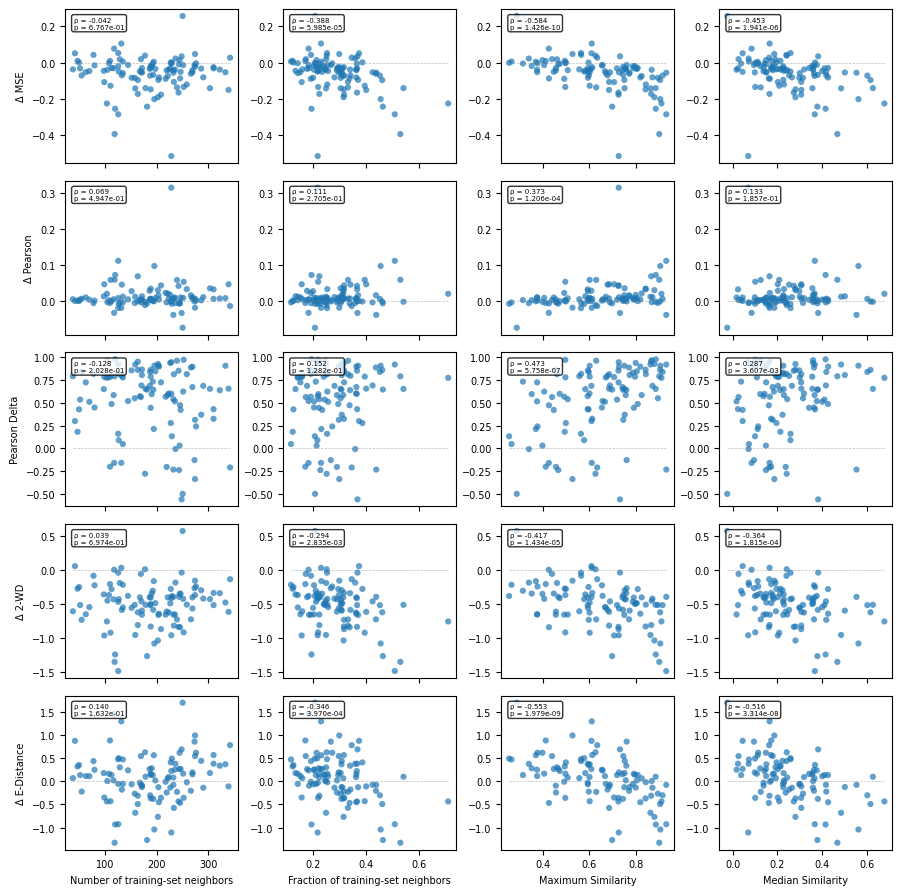

In [ ]:
plot_scatter_with_regression(result_combined, use_spearman=True, 
                             y_cols = ['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance'],
                             save_path=f"../data/final_plots/metric_correlation_scatter_{dataset}_{split}.pdf")

## combined all datasets

In [ ]:
result_list = []
pert_adata_path="../data/preprocessed_replogle_2022_k562_gwps.h5ad"
for dataset in  ['replogle_k562', 'replogle_rpe1', 'nadig_jurkat', 'nadig_hepg2']:
    adata = sc.read_h5ad(f"../data/preprocessed_{dataset}.h5ad")

    for split in [1, 2, 3]:
        split_path = f"../data/splits/{dataset}_single_{split}_0.75.pkl"
        gfm = GFM(
            adata=adata,
            split_dict_path=split_path,
            output_dir=f"../data/gfm/{dataset}/split_{split}/",
            device=device
        )
        gfm.initialize_fm(graph_type="go+pert+ppi", pert_encoding="gat", pert_adata_path=pert_adata_path)
        result_dict = {
            'GFM': [f"../data/gfm/{dataset}/split_{split}/results_test_gfm_go+gwps+ppi_gat.csv"],
            'Perturb train': [f"../data/pert_train/{dataset}/results_test_{split}.csv"]
        }
        result_combined = combine_results(result_dict, baseline_model="Perturb train")
        pert_graph_info = get_pert_graph_info(gfm, gfm.split.split_dict['test'])
        add_pert_graph_metrics(result_combined, pert_graph_info)
        result_combined['split'] = split
        result_combined['dataset'] = dataset
        result_list.append(result_combined)

result_all = pd.concat(result_list, ignore_index=True)

In [ ]:
result_all.head()

,mse,pearson,spearman,mmd,pearson_delta,w2d,e_distance,condition,split,model,n_source_nodes_trained,train_node_ratio,max_sim,median_sim,dataset
0,-0.048766,-0.007478,0.000000,0.156272,0.090054,-0.434850,0.501423,MRPS14+ctrl,1,GFM,126,0.215017,0.577982,0.258496,replogle_k562
1,-0.175831,0.044111,0.018045,0.103384,0.719255,-0.875378,-0.355630,EIF3M+ctrl,1,GFM,208,0.316109,0.726302,0.306558,replogle_k562
2,-0.135953,0.059218,0.079699,0.064929,0.954350,-0.732856,-0.227182,SNAPC3+ctrl,1,GFM,239,0.331025,0.630097,0.125640,replogle_k562
3,-0.029846,0.005016,0.003008,0.056765,0.859069,-0.663936,-0.094224,ELP5+ctrl,1,GFM,171,0.183476,0.455992,0.138405,replogle_k562
4,-0.039252,-0.002429,0.022556,0.025218,0.959807,-0.457822,0.006299,POLA1+ctrl,1,GFM,104,0.246445,0.868944,0.359768,replogle_k562


In [ ]:
result_all.to_csv(f"../data/final_plots_data/correlation_dotplot_graph_metrics_new.csv", index=False)

In [ ]:
result_all = pd.read_csv(f"../data/final_plots_data/correlation_dotplot_graph_metrics_new.csv")

In [ ]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_cols = ['n_source_nodes_trained', 'train_node_ratio', 'max_sim', 'median_sim']
y_cols = ['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance']

x_labels = {
    'n_source_nodes_trained': 'Train neighbors',
    'train_node_ratio': 'Train-neighbor fraction',
    'max_sim': 'Max similarity',
    'median_sim': 'Median similarity',
}

y_labels = {
        'mse': 'Δ MSE',
        'pearson': 'Δ Pearson',
        'pearson_delta': 'Pearson Delta',
        'spearman': 'Δ Spearman',
        'mmd': 'Δ MMD',
        'w2d': 'Δ 2-WD',
        'e_distance': 'Δ E-Distance'
    }

def fisher_mean(rhos):
    rhos = np.asarray(rhos)
    rhos = np.clip(rhos, -0.999999, 0.999999)
    return np.tanh(np.mean(np.arctanh(rhos)))

In [ ]:
corr_rows = []

for (dataset, split), group in result_all.groupby(['dataset', 'split']):
    for x_col in x_cols:
        for y_col in y_cols:
            valid = group[[x_col, y_col]].dropna()

            if len(valid) < 3:
                continue

            rho, p_value = spearmanr(valid[x_col], valid[y_col])

            corr_rows.append({
                'dataset': dataset,
                'split': split,
                'x_col': x_col,
                'y_col': y_col,
                'rho': rho,
                'p_value': p_value,
            })

corr_by_split = pd.DataFrame(corr_rows)

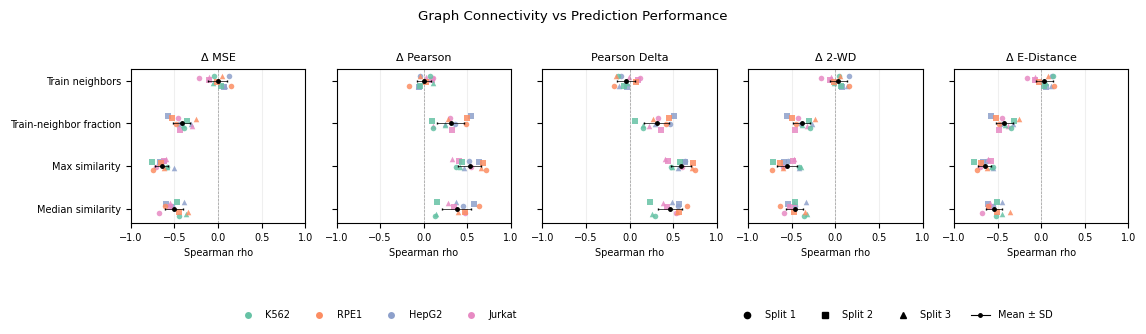

In [ ]:
import seaborn as sns
from matplotlib.lines import Line2D

summary = (
    corr_by_split
    .groupby(['x_col', 'y_col'])
    .agg(
        mean_rho=('rho', fisher_mean),
        sd_rho=('rho', 'std'),
        n=('rho', 'size'),
    )
    .reset_index()
)
summary['sd_rho'] = summary['sd_rho'].fillna(0)

plot_order = list(reversed(x_cols))
fig, axes = plt.subplots(1, len(y_cols), figsize=(2.3 * len(y_cols), 2.8), sharey=True, sharex=True)
if len(y_cols) == 1:
    axes = [axes]

dataset_order = [
    d for d in ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']
    if d in corr_by_split['dataset'].unique()
 ]
if not dataset_order:
    dataset_order = sorted(corr_by_split['dataset'].unique())
palette = dict(zip(dataset_order, sns.color_palette('Set2', len(dataset_order))))

split_order = sorted(corr_by_split['split'].astype(int).unique())
marker_cycle = ['o', 's', '^', 'D', 'P', 'X']
split_markers = {str(s): marker_cycle[i % len(marker_cycle)] for i, s in enumerate(split_order)}

for ax, y_col in zip(axes, y_cols):
    subset = corr_by_split[corr_by_split['y_col'] == y_col].copy()
    subset['split'] = subset['split'].astype(str)
    subset = subset.dropna(subset=['rho', 'x_col'])

    stats = (
        summary[summary['y_col'] == y_col]
        .set_index('x_col')
        .reindex(plot_order)
        .reset_index()
    )

    y_map = {x_name: i for i, x_name in enumerate(plot_order)}
    subset['y_base'] = subset['x_col'].map(y_map).astype(float)
    rng = np.random.default_rng(42)
    subset['y'] = subset['y_base'] + rng.uniform(-0.18, 0.18, len(subset))

    for _, row in subset.iterrows():
        ax.scatter(
            row['rho'],
            row['y'],
            color=palette.get(row['dataset'], 'gray'),
            marker=split_markers.get(row['split'], 'o'),
            s=16,
            linewidth=0,
            alpha=0.85,
            zorder=2,
        )

    y_positions = np.arange(len(plot_order))
    ax.errorbar(
        stats['mean_rho'],
        y_positions,
        xerr=stats['sd_rho'],
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=0.5,
        capsize=1,
        markersize=2.5,
        zorder=4,
    )

    ax.axvline(0, color='0.6', linestyle='--', linewidth=0.5)
    ax.set_title(y_labels[y_col], fontsize=8)
    ax.set_xlim(-1.0, 1.0)
    ax.tick_params(axis='x', labelsize=7)
    ax.set_xlabel('Spearman rho', fontsize=7)
    ax.grid(axis='x', alpha=0.2)
    ax.set_yticks(range(len(plot_order)))

axes[0].set_yticklabels([x_labels[x] for x in plot_order], fontsize=7)
axes[0].tick_params(axis='y', labelleft=True, left=True)
axes[0].set_ylabel('')
for ax in axes[1:]:
    ax.tick_params(axis='y', labelleft=False)
    ax.set_ylabel('')

dataset_map = {
    'replogle_k562': 'K562',
    'replogle_rpe1': 'RPE1',
    'nadig_hepg2': 'HepG2',
    'nadig_jurkat': 'Jurkat',
}

dataset_handles = [
    Line2D([0], [0], marker='o', linestyle='', color=palette[d], markeredgewidth=0, markersize=5, label=dataset_map.get(d, d))
    for d in dataset_order
]
split_handles = [
    Line2D([0], [0], marker=split_markers[str(s)], linestyle='', color='black', markersize=4.5, label=f'Split {s}')
    for s in split_order
]
mean_handle = [
    Line2D([0], [0], marker='o', linestyle='-', color='black', markersize=2.5, linewidth=0.8, label='Mean ± SD')
]

fig.legend(handles=dataset_handles, title=None, loc='lower center', ncol=min(4, len(dataset_handles)), frameon=False, bbox_to_anchor=(0.33, -0.12), fontsize=7, title_fontsize=8)
fig.legend(handles=split_handles + mean_handle, title=None, loc='lower center', ncol=len(split_handles) + 1, frameon=False, bbox_to_anchor=(0.78, -0.12), fontsize=7, title_fontsize=8)

fig.suptitle('Graph Connectivity vs Prediction Performance', y=1.02)
plt.tight_layout(rect=(0, 0.09, 1, 1))
plt.savefig('../data/final_plots/correlation_dotplot_graph_metrics_new.pdf', dpi=300, bbox_inches='tight')
plt.show()